# 26. 변형 표현 LLM Baseline

## 이 Notebook이 답하는 질문 하나

**같은 뜻의 한국어 향 표현을 다르게 쓰면, 사전 없이 LLM만으로 같은 accord에 도착하는가?**

`달콤한`과 `달큰한`은 같은 말이다. 사용자 A는 앞을, 사용자 B는 뒤를 쓴다.
둘이 다른 accord로 가면 같은 취향에 다른 향수가 추천된다.

이 질문의 답이 Domain Lexicon의 규모를 정한다.
LLM이 알아서 처리하면 사전은 작아도 되고, 못 하면 변형어 층을 사전이 담아야 한다.

## 0. 실행 조건과 한계

**측정 설계에서 가장 중요한 것** — 표준형과 변형형을 **서로 다른 요청**으로 보낸다.
같은 요청에 나란히 넣으면 모델이 둘을 보고 억지로 일관되게 답할 수 있어 측정이 무너진다.

**정답을 사람이 정하지 않는다.** `달큰한`의 정답이 무엇인지 정하는 순간 그것도 판단이 된다.
두 답이 서로 같은지만 본다.

**한계 — 결과를 읽을 때 반드시 함께 볼 것**

- 21쌍은 팀 문서 `perfume_14families_korean_descriptors.md`의 20-B / 19-B 장에서 **목적 표집**했다.
  무작위 표본이 아니므로 이 비율을 전체 한국어 향 표현의 성능으로 일반화하지 않는다.
- **단일 실행이다.** 반복 측정이나 온도 변화 실험을 하지 않았다.
- 모델 하나(`gpt-5.4-nano`)만 측정했다.
- "완전 일치"는 엄격한 기준이다. 부분 일치와 검색 결과 겹침을 함께 보고한다.

**하지 않는 것** — Golden Set 수정, 기존 Notebook 수정, 사전 구축, Retrieval 변경.

In [1]:
import hashlib
import json
import pathlib
import re
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

pd.set_option("display.max_colwidth", 40)
pd.set_option("display.width", 200)

# False면 저장된 응답으로 재채점한다. API를 호출하지 않는다.
FORCE_RERUN = False
# True면 계산과 표시만 하고 파일을 만들지 않는다.
REPORT_ONLY = False

MODEL_NAME = "gpt-5.4-nano"
PROMPT_VERSION = "variant_accord_v1"
SELECTION_SEED = 42
TOP_N = 50

print("FORCE_RERUN:", FORCE_RERUN, "/ REPORT_ONLY:", REPORT_ONLY)

FORCE_RERUN: False / REPORT_ONLY: False


## 1. 경로 · 입력 해싱 · 쓰기 가드

25번과 같은 방식이다. 출력은 `analysis_outputs/26_*`만 허용한다.

In [2]:
PROJECT_ROOT = pathlib.Path.cwd()
OUTPUT_DIR = PROJECT_ROOT / "analysis_outputs"

INPUT_PATHS = {
    "checkpoint": OUTPUT_DIR / "26_variant_llm_checkpoint.json",
    "accord_dictionary": OUTPUT_DIR / "10_accord_dictionary.csv",
    "perfumes": PROJECT_ROOT / "perfumes.csv",
}
OUTPUT_PATHS = {
    "pairs": OUTPUT_DIR / "26_variant_pair_results.csv",
    "overlap": OUTPUT_DIR / "26_variant_retrieval_overlap.csv",
    "summary": OUTPUT_DIR / "26_variant_llm_summary.md",
}


def sha256_file(path):
    digest = hashlib.sha256()
    with pathlib.Path(path).open("rb") as handle:
        for chunk in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()


missing = [str(p) for p in INPUT_PATHS.values() if not p.is_file()]
if missing:
    raise FileNotFoundError(f"필수 입력이 없습니다: {missing}")
input_hashes_before = {k: sha256_file(v) for k, v in INPUT_PATHS.items()}

FROZEN_FILES = {p.resolve() for p in INPUT_PATHS.values()}


def write_output(path, writer):
    path = pathlib.Path(path).resolve()
    if path.parent != OUTPUT_DIR.resolve():
        raise RuntimeError(f"쓰기 허용 디렉터리가 아닙니다: {path}")
    if not path.name.startswith("26_"):
        raise RuntimeError(f"26_ prefix가 아닌 출력은 금지합니다: {path.name}")
    if path in FROZEN_FILES:
        raise RuntimeError(f"보호 파일 덮어쓰기 시도: {path.name}")
    if REPORT_ONLY:
        print(f"[REPORT_ONLY] 저장 생략: {path.name}")
        return None
    writer(path)
    print(f"저장: {path.name}")
    return path


display(pd.Series(input_hashes_before, name="sha256").str.slice(0, 16).to_frame())

,sha256
checkpoint,b1c798b3f175c033
accord_dictionary,567e91370e575731
perfumes,cec1ea0b49885303


## 2. 사전 등록 — API를 부르기 전에 고정한다

변형어 쌍, 프롬프트, 채점 규칙을 여기서 확정한다. 결과를 본 뒤에 바꾸지 않는다.

쌍의 출처는 전부 팀 문서다. 제가 만들어낸 쌍은 없다.

- `20-B A` 표기 변형 — 쿰쿰한/쓸쿰한, 상큼한/상콤한, 뽀송한/보송한, 폭닥한/폭신한, 매캐한/매쾌한
- `20-B B` 커뮤니티 축약어 — 화플, 그리너리함, 바닐라리함
- `20-B D` 같은 대상 다른 비유 — 절간 냄새, 쾌남 스킨, 에프킬라, 비 온 뒤 숲
- `19-B A` 외래어 파생 관형어 — 우디한, 파우더리한
- `19-D` 방언 — 달달한, 달큰한

In [3]:
# (표준형, 변형형, 출처, 유형)
PAIRS = [
    ("달콤한",        "달큰한",      "19-D 방언",              "철자 변형"),
    ("달콤한",        "달달한",      "19-D 방언",              "철자 변형"),
    ("쿰쿰한",        "쓸쿰한",      "20-B A [S27]",           "방언·의태어"),
    ("쿰쿰한",        "퀴퀴한",      "20-B A",                 "방언·의태어"),
    ("쿰쿰한",        "쾨쾨한",      "20-B A",                 "방언·의태어"),
    ("상큼한",        "상콤한",      "20-B A 구어 변형",        "철자 변형"),
    ("뽀송한",        "보송한",      "20-B A",                 "철자 변형"),
    ("폭닥한",        "폭신한",      "20-B A",                 "방언·의태어"),
    ("매캐한",        "매쾌한",      "20-B A [S48]",           "방언·의태어"),
    ("우디",          "우디한",      "19-B A 정착 외래어",      "외래어 파생"),
    ("파우더리",      "파우더리한",  "19-B A 정착 외래어",      "외래어 파생"),
    ("그린 노트",     "그리너리한",  "20-B B 축약어 [S04]",     "외래어 파생"),
    ("바닐라",        "바닐라리한",  "20-B B 축약어 [S19]",     "외래어 파생"),
    ("화이트 플로럴", "화플",        "20-B B 축약어 [S52]",     "커뮤니티 은어"),
    ("인센스",        "절간 냄새",   "20-B D 비유",             "문화적 비유"),
    ("인센스",        "향 피운 방",  "20-B D 비유",             "문화적 비유"),
    ("남성 스킨",     "쾌남 스킨",   "20-B D 비유",             "문화적 비유"),
    ("남성 스킨",     "바버샵",      "20-B D 비유",             "문화적 비유"),
    ("인공 시트러스", "에프킬라",    "20-B D 비유",             "문화적 비유"),
    ("오크모스",      "비 온 뒤 숲", "20-B D 비유",             "문화적 비유"),
    ("오크모스",      "젖은 흙",     "20-B D 비유",             "문화적 비유"),
]

accord_df = pd.read_csv(INPUT_PATHS["accord_dictionary"])
ALLOWED = set(accord_df["accord"])
accords_sorted = sorted(ALLOWED)

SYSTEM_PROMPT = (
    "당신은 한국어 향 표현을 Fragrantica accord로 변환합니다.\n"
    "아래 허용 목록에 있는 accord 이름만 사용하세요. 목록에 없는 이름을 만들지 마세요.\n"
    "표현 하나당 최대 3개까지 고르고, 판단할 수 없으면 빈 배열로 두세요.\n"
    "설명, 주석, Markdown 없이 JSON object 하나만 반환하세요.\n\n"
    f"허용 accord ({len(accords_sorted)}개): {', '.join(accords_sorted)}\n\n"
    '출력 형식: {"results": [{"expression": "표현", "accords": ["accord1", "accord2"]}]}'
)
PROMPT_SHA256 = hashlib.sha256(SYSTEM_PROMPT.encode("utf-8")).hexdigest()

# 채점 규칙 (사전 등록)
#   완전 일치 : 두 accord 집합이 같다
#   부분 일치 : 교집합이 있다
#   불일치    : 교집합이 없다
#   포기      : 한쪽 또는 양쪽이 빈 배열
VERDICTS = ["완전 일치", "부분 일치", "불일치", "표준형만 포기", "변형형만 포기", "둘 다 포기"]

print(f"쌍 {len(PAIRS)}개 / 표현 {len({p[0] for p in PAIRS}) + len({p[1] for p in PAIRS})}개")
print(f"허용 accord {len(ALLOWED)}개 / prompt SHA256 {PROMPT_SHA256[:16]}...")
display(pd.DataFrame(PAIRS, columns=["표준형", "변형형", "출처", "유형"]).groupby("유형").size().to_frame("쌍"))

쌍 21개 / 표현 36개
허용 accord 92개 / prompt SHA256 243c87037e965910...


,쌍
유형,
문화적 비유,7
방언·의태어,5
외래어 파생,4
철자 변형,4
커뮤니티 은어,1


## 3. 응답 확보 — 기본은 저장된 체크포인트

`FORCE_RERUN = False`면 `26_variant_llm_checkpoint.json`을 읽고 **API를 호출하지 않는다.**
체크포인트에는 원본 응답 전문이 들어 있어 재호출 없이 재채점할 수 있다.

체크포인트의 prompt SHA256이 위에서 계산한 값과 다르면 중단한다.
프롬프트가 바뀐 채로 옛 응답을 채점하는 것을 막기 위해서다.

In [4]:
def call_gms(expressions):
    """FORCE_RERUN=True일 때만 사용한다."""
    import os
    import requests
    from dotenv import load_dotenv

    load_dotenv(PROJECT_ROOT / ".env")
    key = os.getenv("GMS_KEY")
    if not key:
        raise RuntimeError(".env에서 GMS_KEY를 찾지 못했습니다.")
    user = "다음 표현을 각각 변환하세요.\n" + "\n".join(f"- {e}" for e in expressions)
    started = time.perf_counter()
    response = requests.post(
        "https://gms.ssafy.io/gmsapi/api.openai.com/v1/chat/completions",
        headers={"Authorization": f"Bearer {key}", "Content-Type": "application/json"},
        json={"model": MODEL_NAME,
              "messages": [{"role": "developer", "content": SYSTEM_PROMPT},
                           {"role": "user", "content": user}]},
        timeout=120,
    )
    response.raise_for_status()
    body = response.json()
    return {"user_prompt": user,
            "content": body["choices"][0]["message"]["content"],
            "usage": body.get("usage", {}),
            "model_reported": body.get("model"),
            "latency_seconds": time.perf_counter() - started}


rng = np.random.default_rng(SELECTION_SEED)
group_standard = list(dict.fromkeys(p[0] for p in PAIRS))
group_variant = [p[1] for p in PAIRS]

if FORCE_RERUN:
    print("API를 호출합니다. 표준형과 변형형을 분리해 보냅니다.")
    requests_payload = {"standard": call_gms(group_standard),
                        "variant": call_gms(group_variant)}
    checkpoint = {"meta": {"model": MODEL_NAME, "gateway": "SSAFY GMS",
                           "prompt_version": PROMPT_VERSION, "prompt_sha256": PROMPT_SHA256,
                           "selection_seed": SELECTION_SEED},
                  "system_prompt": SYSTEM_PROMPT, "requests": requests_payload}
else:
    checkpoint = json.loads(INPUT_PATHS["checkpoint"].read_text(encoding="utf-8"))
    if checkpoint["meta"]["prompt_sha256"] != PROMPT_SHA256:
        raise RuntimeError("체크포인트의 prompt SHA256이 현재 프롬프트와 다릅니다. 재채점을 중단합니다.")
    print("체크포인트에서 응답을 읽었습니다. API 호출 없음.")

meta = checkpoint["meta"]
print(f"  model={meta['model']} / prompt={meta['prompt_version']} / seed={meta['selection_seed']}")
for tag, payload in checkpoint["requests"].items():
    print(f"  [{tag}] tokens={payload['usage'].get('total_tokens')} "
          f"model_reported={payload.get('model_reported')}")

체크포인트에서 응답을 읽었습니다. API 호출 없음.
  model=gpt-5.4-nano / prompt=variant_accord_v1 / seed=42
  [standard] tokens=700 model_reported=gpt-5.4-nano-2026-03-17
  [variant] tokens=858 model_reported=gpt-5.4-nano-2026-03-17


## 4. 응답 파싱과 허용 목록 검증

모델이 허용 목록 밖의 accord 이름을 만들었는지 센다. 이 수치는 그 자체로 결과다.

In [5]:
def parse_answers(payload):
    text = payload["content"].strip()
    if text.startswith("```"):
        text = text.split("```")[1].removeprefix("json").strip()
    parsed = json.loads(text)
    return {x["expression"]: list(x.get("accords", [])) for x in parsed["results"]}


answers = {tag: parse_answers(payload) for tag, payload in checkpoint["requests"].items()}
ans_std, ans_var = answers["standard"], answers["variant"]

missing_std = [e for e in group_standard if e not in ans_std]
missing_var = [e for e in group_variant if e not in ans_var]
if missing_std or missing_var:
    raise ValueError(f"응답 누락 — 표준형 {missing_std} / 변형형 {missing_var}")

out_of_vocab = sorted({
    a for mapping in (ans_std, ans_var) for values in mapping.values()
    for a in values if a not in ALLOWED
})
print(f"허용 목록 밖 accord: {len(out_of_vocab)}종 {out_of_vocab}")
print("→ 92개 목록을 프롬프트에 명시했음에도 발생한다면 enum 강제가 필요하다는 근거다.")

허용 목록 밖 accord: 3종 ['dry', 'rain', 'sharp']
→ 92개 목록을 프롬프트에 명시했음에도 발생한다면 enum 강제가 필요하다는 근거다.


## 5. 쌍별 일치 판정

In [6]:
rows = []
for std, var, source, kind in PAIRS:
    raw_a, raw_b = ans_std[std], ans_var[var]
    sa, sb = set(raw_a) & ALLOWED, set(raw_b) & ALLOWED
    first_a = next((x for x in raw_a if x in ALLOWED), "")
    first_b = next((x for x in raw_b if x in ALLOWED), "")
    if not sa and not sb:   verdict = "둘 다 포기"
    elif not sb:            verdict = "변형형만 포기"
    elif not sa:            verdict = "표준형만 포기"
    elif sa == sb:          verdict = "완전 일치"
    elif sa & sb:           verdict = "부분 일치"
    else:                   verdict = "불일치"
    rows.append({
        "표준형": std, "변형형": var, "유형": kind, "출처": source, "판정": verdict,
        "표준형 accords": ", ".join(sorted(sa)) or "-",
        "변형형 accords": ", ".join(sorted(sb)) or "-",
        "교집합": ", ".join(sorted(sa & sb)) or "-",
        "표준형 1순위": first_a, "변형형 1순위": first_b,
        "1순위 일치": bool(first_a) and first_a == first_b,
        "목록 밖": ", ".join(sorted((set(raw_a) | set(raw_b)) - ALLOWED)),
    })

pair_df = pd.DataFrame(rows)
n = len(pair_df)
exact = int((pair_df["판정"] == "완전 일치").sum())
partial = int((pair_df["판정"] == "부분 일치").sum())
first_match = int(pair_df["1순위 일치"].sum())

print(f"완전 일치 {exact}/{n} = {exact/n:.0%}")
print(f"교집합 존재 {exact + partial}/{n} = {(exact + partial)/n:.0%}")
print(f"1순위 일치 {first_match}/{n} = {first_match/n:.0%}")
display(pair_df["판정"].value_counts().to_frame("쌍"))
display(pair_df[["표준형", "변형형", "유형", "판정", "표준형 accords", "변형형 accords"]])

완전 일치 2/21 = 10%
교집합 존재 11/21 = 52%
1순위 일치 7/21 = 33%


,쌍
판정,
불일치,10
부분 일치,9
완전 일치,2


,표준형,변형형,유형,판정,표준형 accords,변형형 accords
0,달콤한,달큰한,철자 변형,부분 일치,"gourmand, sweet","caramel, sweet"
1,달콤한,달달한,철자 변형,부분 일치,"gourmand, sweet","sweet, vanilla"
2,쿰쿰한,쓸쿰한,방언·의태어,부분 일치,"earthy, musky","musky, soapy"
3,쿰쿰한,퀴퀴한,방언·의태어,부분 일치,"earthy, musky","earthy, mossy"
4,쿰쿰한,쾨쾨한,방언·의태어,불일치,"earthy, musky",alcohol
5,상큼한,상콤한,철자 변형,완전 일치,"citrus, fresh","citrus, fresh"
6,뽀송한,보송한,철자 변형,부분 일치,"powdery, soapy",powdery
7,폭닥한,폭신한,방언·의태어,불일치,"soft spicy, warm spicy","aldehydic, powdery"
8,매캐한,매쾌한,방언·의태어,불일치,"aldehydic, camphor","citrus, herbal"
9,우디,우디한,외래어 파생,부분 일치,woody,"mossy, woody"


## 6. 그래서 실제로 다른 향수가 나오는가

accord가 다르다는 것과 추천 결과가 다르다는 것은 별개다. 여기서 그 간격을 잰다.

두 방식으로 본다.

- **AND 조건** — 지정한 accord를 모두 가진 향수. Jaccard로 비교
- **점수 방식** — 11번처럼 accord 강도를 합산해 상위 `TOP_N`개. 겹치는 비율로 비교

점수 방식이 실제 Retrieval에 더 가깝다.

In [7]:
perfume_df = pd.read_csv(INPUT_PATHS["perfumes"], usecols=["id", "accords"])
accord_sets = perfume_df["accords"].fillna("").map(
    lambda s: {x.split(":")[0] for x in s.split("|") if x})
accord_weights = perfume_df["accords"].fillna("").map(
    lambda s: {x.split(":")[0]: int(x.split(":")[1]) for x in s.split("|") if ":" in x})
perfume_ids = np.asarray(perfume_df["id"])


def and_match(targets):
    if not targets:
        return None
    return {i for i, st in zip(perfume_ids, accord_sets) if targets <= st}


def score_topn(targets, top_n=TOP_N):
    if not targets:
        return None
    scores = np.fromiter((sum(w.get(a, 0) for a in targets) for w in accord_weights),
                         dtype=float, count=len(perfume_ids))
    if scores.max() == 0:
        return set()
    return set(perfume_ids[np.argsort(-scores)[:top_n]])


overlap_rows = []
# 컬럼명이 한글·공백이라 itertuples의 위치 기반 이름(_5 등)은 쓰지 않는다.
for row in pair_df.to_dict("records"):
    ta = {x.strip() for x in row["표준형 accords"].split(",") if x.strip() != "-"} & ALLOWED
    tb = {x.strip() for x in row["변형형 accords"].split(",") if x.strip() != "-"} & ALLOWED
    a_and, b_and = and_match(ta), and_match(tb)
    a_top, b_top = score_topn(ta), score_topn(tb)
    record = {"표준형": row["표준형"], "변형형": row["변형형"],
              "유형": row["유형"], "판정": row["판정"]}
    if a_and is None or b_and is None:
        record.update({"AND 표준": np.nan, "AND 변형": np.nan, "AND Jaccard": np.nan,
                       f"TOP{TOP_N} 겹침": np.nan})
    else:
        union = a_and | b_and
        record.update({
            "AND 표준": len(a_and), "AND 변형": len(b_and),
            "AND Jaccard": len(a_and & b_and) / len(union) if union else 0.0,
            f"TOP{TOP_N} 겹침": len(a_top & b_top) / TOP_N,
        })
    overlap_rows.append(record)

overlap_df = pd.DataFrame(overlap_rows)
valid = overlap_df.dropna(subset=["AND Jaccard"])
print(f"AND Jaccard        평균 {valid['AND Jaccard'].mean():.1%} / 중앙값 {valid['AND Jaccard'].median():.1%}")
print(f"TOP{TOP_N} 겹침         평균 {valid[f'TOP{TOP_N} 겹침'].mean():.1%} / 중앙값 {valid[f'TOP{TOP_N} 겹침'].median():.1%}")
print(f"TOP{TOP_N}에서 하나도 겹치지 않는 쌍: {int((valid[f'TOP{TOP_N} 겹침'] == 0).sum())}/{len(valid)}")
display(overlap_df)

AND Jaccard        평균 15.9% / 중앙값 0.8%
TOP50 겹침         평균 10.2% / 중앙값 0.0%
TOP50에서 하나도 겹치지 않는 쌍: 15/21


,표준형,변형형,유형,판정,AND 표준,AND 변형,AND Jaccard,TOP50 겹침
0,달콤한,달큰한,철자 변형,부분 일치,138,3745,0.004397,0.00
1,달콤한,달달한,철자 변형,부분 일치,138,24872,0.002566,0.00
2,쿰쿰한,쓸쿰한,방언·의태어,부분 일치,3983,400,0.001371,0.00
3,쿰쿰한,퀴퀴한,방언·의태어,부분 일치,3983,4715,0.122612,0.04
4,쿰쿰한,쾨쾨한,방언·의태어,불일치,3983,154,0.000000,0.00
5,상큼한,상콤한,철자 변형,완전 일치,18826,18826,1.000000,1.00
6,뽀송한,보송한,철자 변형,부분 일치,519,62885,0.008253,0.00
7,폭닥한,폭신한,방언·의태어,불일치,3657,1351,0.000999,0.00
8,매캐한,매쾌한,방언·의태어,불일치,17,4359,0.000229,0.00
9,우디,우디한,외래어 파생,부분 일치,81432,5166,0.063439,0.00


## 7. 유형별 — 여기가 이 실험의 결론이다

어떤 종류의 변형을 LLM이 처리하고 어떤 종류를 못 하는지 나눈다.
사전이 담아야 할 범위가 여기서 정해진다.

,쌍,완전일치,교집합있음,일순위일치,완전일치율,일순위일치율
유형,,,,,,
문화적 비유,7,0,1,0,0%,0%
방언·의태어,5,0,2,0,0%,0%
외래어 파생,4,1,4,4,25%,100%
철자 변형,4,1,4,3,25%,75%
커뮤니티 은어,1,0,0,0,0%,0%


,TOP50 겹침 평균
유형,
문화적 비유,0.3%
방언·의태어,0.8%
외래어 파생,27.0%
철자 변형,25.0%
커뮤니티 은어,0.0%


C:\Users\SSAFY\AppData\Local\Temp\ipykernel_20236\2367553379.py:22: UserWarning: Glyph 50808 (\N{HANGUL SYLLABLE OE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\SSAFY\AppData\Local\Temp\ipykernel_20236\2367553379.py:22: UserWarning: Glyph 47000 (\N{HANGUL SYLLABLE RAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\SSAFY\AppData\Local\Temp\ipykernel_20236\2367553379.py:22: UserWarning: Glyph 50612 (\N{HANGUL SYLLABLE EO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\SSAFY\AppData\Local\Temp\ipykernel_20236\2367553379.py:22: UserWarning: Glyph 54028 (\N{HANGUL SYLLABLE PA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\SSAFY\AppData\Local\Temp\ipykernel_20236\2367553379.py:22: UserWarning: Glyph 49373 (\N{HANGUL SYLLABLE SAENG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\SSAFY\AppData\Local\Temp\ipykernel_20236\2367553379.py:22: UserWarning: Glyph 52384 (\N{HANGUL SYLLABLE CEOL}) missing fro

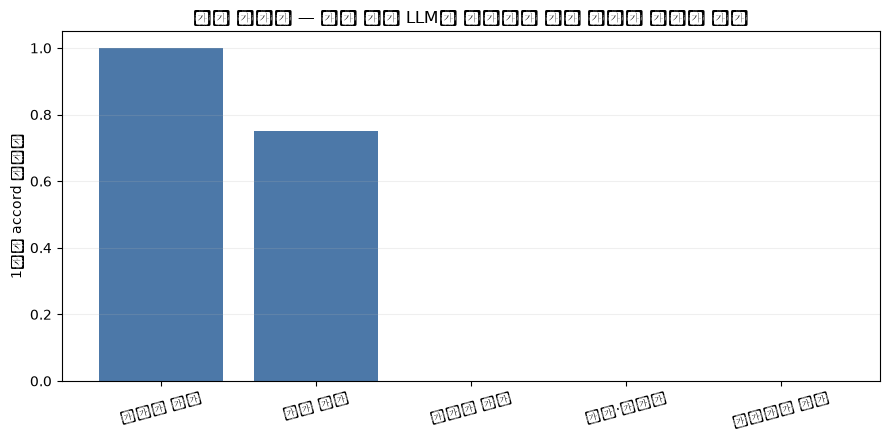

In [8]:
by_kind = pair_df.groupby("유형").agg(
    쌍=("판정", "size"),
    완전일치=("판정", lambda s: int((s == "완전 일치").sum())),
    교집합있음=("판정", lambda s: int(s.isin(["완전 일치", "부분 일치"]).sum())),
    일순위일치=("1순위 일치", "sum"),
).assign(완전일치율=lambda d: (d["완전일치"] / d["쌍"]).map("{:.0%}".format),
         일순위일치율=lambda d: (d["일순위일치"] / d["쌍"]).map("{:.0%}".format))
display(by_kind)

top_col = f"TOP{TOP_N} 겹침"
kind_overlap = overlap_df.dropna(subset=[top_col]).groupby("유형")[top_col].mean()
display(kind_overlap.map("{:.1%}".format).to_frame(f"{top_col} 평균"))

fig, ax = plt.subplots(figsize=(9, 4.5))
order = by_kind.sort_values("일순위일치", ascending=False).index
ax.bar(order, [by_kind.loc[k, "일순위일치"] / by_kind.loc[k, "쌍"] for k in order], color="#4C78A8")
ax.set_ylim(0, 1.05)
ax.set_ylabel("1순위 accord 일치율")
ax.set_title("변형 유형별 — 사전 없이 LLM이 표준형과 같은 곳으로 보내는 비율")
ax.grid(axis="y", alpha=0.2)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## 8. 저장

In [9]:
summary_lines = []
for kind in by_kind.index:
    r = by_kind.loc[kind]
    summary_lines.append(f"| {kind} | {r['쌍']} | {r['완전일치율']} | {r['일순위일치율']} |")
kind_table = "\n".join(summary_lines)

summary_text = f"""# 변형 표현 LLM Baseline

## 질문

같은 뜻의 한국어 향 표현을 다르게 쓰면, 사전 없이 LLM만으로 같은 accord에 도착하는가.

## 설계

- 팀 문서 `perfume_14families_korean_descriptors.md` 20-B / 19-B / 19-D 장에서 변형어 {n}쌍을 목적 표집
- **표준형과 변형형을 서로 다른 요청으로 분리** — 같은 요청에 넣으면 모델이 억지로 일관되게 답할 수 있다
- 정답을 사람이 정하지 않고 두 답이 같은지만 본다
- Model `{meta['model']}` / Prompt `{meta['prompt_version']}` / SHA256 `{PROMPT_SHA256[:16]}...`

## 결과

| 지표 | 값 |
|---|---|
| accord 집합 완전 일치 | {exact}/{n} ({exact/n:.0%}) |
| 교집합 존재 | {exact + partial}/{n} ({(exact + partial)/n:.0%}) |
| 1순위 accord 일치 | {first_match}/{n} ({first_match/n:.0%}) |
| AND 검색 Jaccard 중앙값 | {valid['AND Jaccard'].median():.1%} |
| 점수 검색 TOP{TOP_N} 겹침 중앙값 | {valid[top_col].median():.1%} |
| TOP{TOP_N}에서 전혀 겹치지 않는 쌍 | {int((valid[top_col] == 0).sum())}/{len(valid)} |
| 허용 목록 밖 accord 생성 | {len(out_of_vocab)}종 {out_of_vocab} |

## 유형별

| 유형 | 쌍 | 완전 일치 | 1순위 일치 |
|---|---|---|---|
{kind_table}

## 해석

LLM 단독으로는 같은 뜻의 표현을 같은 accord로 보내지 못한다.
accord 집합이 완전히 일치한 것은 {exact}/{n}이고, 점수 기반 상위 {TOP_N}개에서
전혀 겹치지 않는 쌍이 {int((valid[top_col] == 0).sum())}개다.
즉 같은 취향을 다르게 표현한 두 사용자가 서로 다른 향수를 추천받는다.

유형별로 갈린다. **철자 변형과 외래어 파생은 처리하고, 방언·의태어와 커뮤니티 은어와
문화적 비유는 처리하지 못한다.** 후자 셋은 학습 데이터에 드문 한국 향수 커뮤니티 고유 어휘다.

허용 목록 92개를 프롬프트에 명시했음에도 목록 밖 이름을 만들었다.
출력을 JSON Schema enum으로 강제해야 한다.

## 한계

- {n}쌍은 목적 표집이며 무작위 표본이 아니다. 이 비율을 전체 성능으로 일반화하지 않는다
- 단일 실행이다. 반복 측정이나 온도 변화 실험을 하지 않았다
- 모델 하나만 측정했다
- "완전 일치"는 엄격한 기준이므로 부분 일치와 검색 겹침을 함께 보고했다
- 1순위 비교는 응답 순서에 의존한다. `상큼한`/`상콤한`은 집합이 같은데 순서가 달라 1순위로는 불일치가 됐다
"""

write_output(OUTPUT_PATHS["pairs"], lambda p: pair_df.to_csv(p, index=False, encoding="utf-8-sig"))
write_output(OUTPUT_PATHS["overlap"], lambda p: overlap_df.to_csv(p, index=False, encoding="utf-8-sig"))
write_output(OUTPUT_PATHS["summary"], lambda p: p.write_text(summary_text, encoding="utf-8"))

if not REPORT_ONLY:
    reread = pd.read_csv(OUTPUT_PATHS["pairs"])
    if len(reread) != n:
        raise ValueError("저장 결과 행 수 불일치")
    print(f"검증 통과 — pair {len(reread)}행 / overlap {len(overlap_df)}행")

저장: 26_variant_pair_results.csv
저장: 26_variant_retrieval_overlap.csv
저장: 26_variant_llm_summary.md
검증 통과 — pair 21행 / overlap 21행


## 9. 가드 검증

In [10]:
input_hashes_after = {k: sha256_file(v) for k, v in INPUT_PATHS.items()}
changed = [k for k in input_hashes_before if input_hashes_before[k] != input_hashes_after[k]]
if changed:
    raise RuntimeError(f"입력이 변경됐습니다: {changed}")
print("입력 해시 동일")
print("생성한 출력:")
for label, path in OUTPUT_PATHS.items():
    print(f"  {label}: {path.name}{'' if path.is_file() else '  (REPORT_ONLY로 미생성)'}")

입력 해시 동일
생성한 출력:
  pairs: 26_variant_pair_results.csv
  overlap: 26_variant_retrieval_overlap.csv
  summary: 26_variant_llm_summary.md
